# Notebook 07 - Evaluasi Final
**Proyek:** Pulsevera - Predict, Prevent, Prevail  
**Role:** AI Engineer  
**Tujuan:** Membandingkan performa model ML Baseline (Logistic Regression) dan model Deep Learning secara menyeluruh, lalu menentukan model mana yang dipakai di API.

---

## Setup & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    mean_absolute_error,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')
print('Semua library berhasil diimport.')

I0000 00:00:1780047037.314860   28267 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780047037.315616   28267 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780047037.359172   28267 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Semua library berhasil diimport.


I0000 00:00:1780047038.446785   28267 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780047038.447177   28267 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# --- Setup Path ---
BASE_DIR   = Path('..')
DATA_DIR   = BASE_DIR / 'data' / 'final'
MODELS_DIR = BASE_DIR / 'ml-api' / 'models'

print(f'Models : {MODELS_DIR}')

Models : ../ml-api/models


---
## Step 1: Load Data & Model
Load data test, scaler, threshold, dan kedua model yang sudah disimpan.

In [3]:
# Load data test
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

# Konversi kolom bool ke float32
bool_cols = X_test.select_dtypes(include='bool').columns.tolist()
X_test[bool_cols] = X_test[bool_cols].astype('float32')

# Load scaler dan transform X_test
scaler        = joblib.load(MODELS_DIR / 'scaler.pkl')
X_test_scaled = scaler.transform(X_test).astype('float32')

# Load threshold yang sudah ditentukan
threshold = joblib.load(MODELS_DIR / 'threshold.pkl')

print(f'X_test  : {X_test_scaled.shape}')
print(f'y_test  : {y_test.shape}')
print(f'Threshold: {threshold}')

X_test  : (89027, 46)
y_test  : (89027,)
Threshold: 0.3


In [4]:
# Load model ML (Logistic Regression)
ml_model = joblib.load(MODELS_DIR / 'pulsevera_ml_model.pkl')
print(f'ML Model  : {type(ml_model).__name__}')

# Load model Deep Learning
# custom_objects diperlukan karena model pakai Focal Loss yang kita buat sendiri
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = tf.exp(-bce)
        return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)
    return loss

dl_model = keras.models.load_model(
    str(MODELS_DIR / 'pulsevera_dl_model.keras'),
    custom_objects={'loss': focal_loss()}
)
print(f'DL Model  : {dl_model.name}')

ML Model  : LogisticRegression
DL Model  : pulsevera_model


E0000 00:00:1780047038.856049   28267 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780047038.856379   28327 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780047038.875335   28267 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


---
## Step 2: Prediksi Kedua Model
Jalankan prediksi menggunakan threshold yang sudah ditentukan.

In [5]:
# Prediksi ML Model
y_proba_ml = ml_model.predict_proba(X_test_scaled)[:, 1]
y_pred_ml  = (y_proba_ml >= threshold).astype(int)

# Prediksi DL Model
y_proba_dl = dl_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_dl  = (y_proba_dl >= threshold).astype(int)

print(f'Prediksi ML selesai. Positif terdeteksi: {y_pred_ml.sum():,}')
print(f'Prediksi DL selesai. Positif terdeteksi: {y_pred_dl.sum():,}')

Prediksi ML selesai. Positif terdeteksi: 13,481
Prediksi DL selesai. Positif terdeteksi: 15,265


---
## Step 3: Tabel Perbandingan Metrik
Bandingkan semua metrik kedua model dalam satu tabel.

In [6]:
# Hitung semua metrik untuk kedua model
def get_metrics(y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Recall'    : round(report['1']['recall'], 4),
        'Precision' : round(report['1']['precision'], 4),
        'F1'        : round(report['1']['f1-score'], 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_proba), 4),
        'MAE'       : round(mean_absolute_error(y_true, y_proba), 4),
    }

metrics_ml = get_metrics(y_test, y_pred_ml, y_proba_ml)
metrics_dl = get_metrics(y_test, y_pred_dl, y_proba_dl)

df_compare = pd.DataFrame({
    'Metrik'   : list(metrics_ml.keys()),
    'Target'   : ['≥ 0.85', '≥ 0.70', '≥ 0.20', '≥ 0.65', '≥ 0.80', '≤ 0.02'],
    'ML Model' : list(metrics_ml.values()),
    'DL Model' : list(metrics_dl.values()),
})

print('=== PERBANDINGAN FINAL: ML vs DL ===')
print(df_compare.to_string(index=False))

=== PERBANDINGAN FINAL: ML vs DL ===
   Metrik Target  ML Model  DL Model
 Accuracy ≥ 0.85    0.8714    0.8546
   Recall ≥ 0.70    0.7019    0.7312
Precision ≥ 0.20    0.2615    0.2406
       F1 ≥ 0.65    0.3810    0.3620
  ROC-AUC ≥ 0.80    0.8821    0.8835
      MAE ≤ 0.02    0.1565    0.2292


---
## Step 4: Visualisasi ROC Curve
ROC Curve menunjukkan seberapa baik model membedakan kelas positif dan negatif di berbagai threshold.

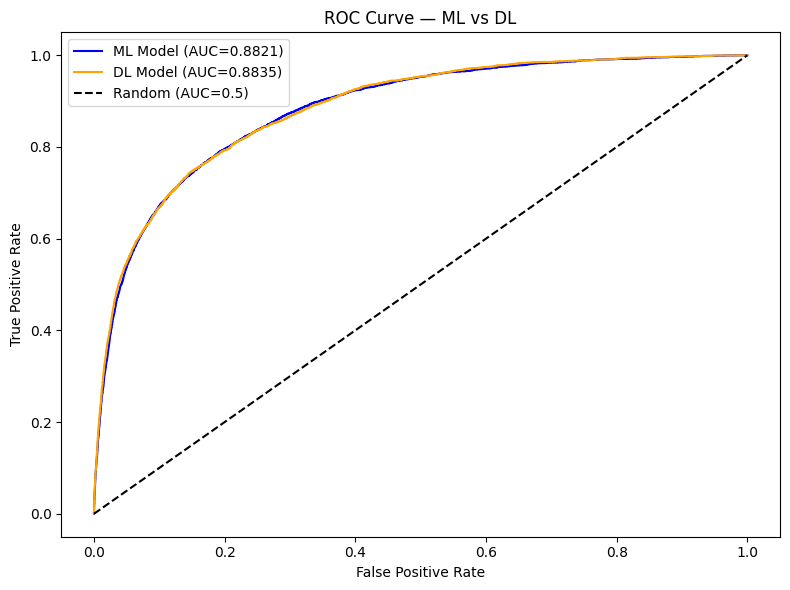

ROC Curve disimpan.


In [7]:
# Plot ROC Curve kedua model dalam satu grafik
fpr_ml, tpr_ml, _ = roc_curve(y_test, y_proba_ml)
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_proba_dl)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ml, tpr_ml, label=f'ML Model (AUC={metrics_ml["ROC-AUC"]})', color='blue')
plt.plot(fpr_dl, tpr_dl, label=f'DL Model (AUC={metrics_dl["ROC-AUC"]})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ML vs DL')
plt.legend()
plt.tight_layout()
plt.savefig('figures/07_roc_curve.png', dpi=150)
plt.show()
print('ROC Curve disimpan.')

---
## Step 5: Confusion Matrix
Confusion matrix menunjukkan detail prediksi benar dan salah per kelas.

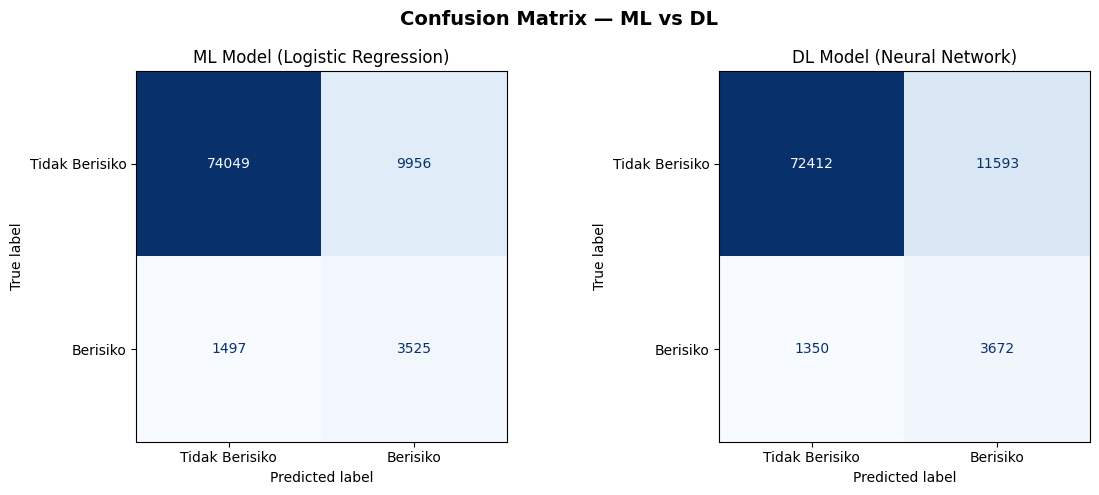

Confusion Matrix disimpan.


In [8]:
# Plot confusion matrix kedua model berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — ML vs DL', fontsize=14, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred_ml, y_pred_dl],
    ['ML Model (Logistic Regression)', 'DL Model (Neural Network)']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Berisiko', 'Berisiko'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('figures/07_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion Matrix disimpan.')

---
## Step 6: Cek Target Metrik Final
Verifikasi apakah kedua model memenuhi target metrik yang ditetapkan.

In [9]:
# Cek target metrik untuk kedua model
targets = {
    'Accuracy' : ('>=', 0.85),
    'Recall'   : ('>=', 0.70),
    'ROC-AUC'  : ('>=', 0.80),
    'MAE'      : ('<=', 0.02),
}

print('=== CEK TARGET METRIK FINAL ===')
print(f'{"Metrik":<12} {"Target":<12} {"ML Model":<12} {"DL Model":<12}')
print('-' * 50)

for metrik, (op, val) in targets.items():
    ml_val  = metrics_ml[metrik]
    dl_val  = metrics_dl[metrik]
    ml_pass = ml_val >= val if op == '>=' else ml_val <= val
    dl_pass = dl_val >= val if op == '>=' else dl_val <= val
    print(f'{metrik:<12} {op}{val:<10} {str(ml_val)+" "+"✅" if ml_pass else str(ml_val)+" ❌":<12} {str(dl_val)+" "+"✅" if dl_pass else str(dl_val)+" ❌":<12}')

=== CEK TARGET METRIK FINAL ===
Metrik       Target       ML Model     DL Model    
--------------------------------------------------
Accuracy     >=0.85       0.8714 ✅     0.8546 ✅    
Recall       >=0.7        0.7019 ✅     0.7312 ✅    
ROC-AUC      >=0.8        0.8821 ✅     0.8835 ✅    
MAE          <=0.02       0.1565 ❌     0.2292 ❌    


---
## Step 7: Pilih Model untuk API
Tentukan model mana yang akan dipakai di FastAPI berdasarkan hasil evaluasi.

In [10]:
# Pilih model terbaik berdasarkan Accuracy dan Recall
# Prioritas: keduanya harus memenuhi target, lalu pilih ROC-AUC tertinggi

ml_lolos = metrics_ml['Accuracy'] >= 0.85 and metrics_ml['Recall'] >= 0.70
dl_lolos = metrics_dl['Accuracy'] >= 0.85 and metrics_dl['Recall'] >= 0.70

if ml_lolos and dl_lolos:
    # Keduanya lolos — pilih ROC-AUC tertinggi
    model_api = 'ML' if metrics_ml['ROC-AUC'] >= metrics_dl['ROC-AUC'] else 'DL'
elif ml_lolos:
    model_api = 'ML'
elif dl_lolos:
    model_api = 'DL'
else:
    # Tidak ada yang lolos semua target — pilih Recall tertinggi
    model_api = 'ML' if metrics_ml['Recall'] >= metrics_dl['Recall'] else 'DL'

print(f'Model yang dipakai di API: {model_api} Model')
print()
if model_api == 'ML':
    print('File: ml-api/models/pulsevera_ml_model.pkl')
else:
    print('File: ml-api/models/pulsevera_dl_model.keras')
print(f'Threshold: {threshold}')

Model yang dipakai di API: DL Model

File: ml-api/models/pulsevera_dl_model.keras
Threshold: 0.3


---
## Ringkasan Notebook 07
Catat hasil evaluasi final dan keputusan model untuk API.

In [11]:
print('=== RINGKASAN NOTEBOOK ===')
print()
print(f'Model untuk API  : {model_api} Model')
print(f'Threshold        : {threshold}')
print()
print('Metrik ML Model:')
for k, v in metrics_ml.items():
    print(f'  {k:<12}: {v}')
print()
print('Metrik DL Model:')
for k, v in metrics_dl.items():
    print(f'  {k:<12}: {v}')
print()
print('File yang dihasilkan:')
print('  - notebooks/figures/07_roc_curve.png')
print('  - notebooks/figures/07_confusion_matrix.png')

=== RINGKASAN NOTEBOOK ===

Model untuk API  : DL Model
Threshold        : 0.3

Metrik ML Model:
  Accuracy    : 0.8714
  Recall      : 0.7019
  Precision   : 0.2615
  F1          : 0.381
  ROC-AUC     : 0.8821
  MAE         : 0.1565

Metrik DL Model:
  Accuracy    : 0.8546
  Recall      : 0.7312
  Precision   : 0.2406
  F1          : 0.362
  ROC-AUC     : 0.8835
  MAE         : 0.2292

File yang dihasilkan:
  - notebooks/figures/07_roc_curve.png
  - notebooks/figures/07_confusion_matrix.png
